<h1>표정 데이터셋을 활용한 표정 분류 인공지능 모델</h1>

In [ ]:
# Kaggle API 토큰 업로드
from google.colab import files
files.upload()

# Kaggle API 토큰을 ~/.kaggle/ 디렉터리로 이동
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Kaggle 데이터셋 다운로드
!kaggle datasets download -d ananthu017/emotion-detection-fer -p '/content/'

# 다운로드한 데이터셋 압축 파일을 해제
import zipfile
with zipfile.ZipFile('/content/emotion-detection-fer.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

Saving kaggle.json to kaggle.json
 95% 62.0M/65.2M [00:00<00:00, 130MB/s]
100% 65.2M/65.2M [00:00<00:00, 131MB/s]


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 훈련 및 검증 데이터의 경로
train_data_dir = '/content/train'
validation_data_dir = '/content/test'

# 이미지 데이터를 전처리하는 함수
def preprocess_image(image):
    image = image / 255.0  # 이미지를 0에서 1 사이의 값으로 정규화
    return image

# 이미지 데이터 증강을 위한 ImageDataGenerator 생성
datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# 훈련 데이터를 불러오는 ImageDataGenerator 생성
train_generator = datagen.flow_from_directory(
    train_data_dir,
    target_size=(48, 48),
    batch_size=32,
    color_mode="grayscale",
    class_mode='categorical',
    subset='training'
)

# 검증 데이터를 불러오는 ImageDataGenerator 생성
validation_generator = datagen.flow_from_directory(
    validation_data_dir,
    target_size=(48, 48),
    batch_size=32,
    color_mode="grayscale",
    class_mode='categorical',
    subset='validation'
)

Found 22968 images belonging to 7 classes.
Found 1432 images belonging to 7 classes.


In [ ]:
# CNN 모델 구성
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(7, activation='softmax'))

# 모델 컴파일
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 모델 훈련
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator
)

Epoch 1/20
718/718 [==============================] - 56s 77ms/step - loss: 1.7510 - accuracy: 0.2869 - val_loss: 1.6069 - val_accuracy: 0.3876
Epoch 2/20
718/718 [==============================] - 53s 74ms/step - loss: 1.5865 - accuracy: 0.3820 - val_loss: 1.4736 - val_accuracy: 0.4288
Epoch 3/20
718/718 [==============================] - 54s 75ms/step - loss: 1.4900 - accuracy: 0.4235 - val_loss: 1.4715 - val_accuracy: 0.4392
Epoch 4/20
718/718 [==============================] - 54s 75ms/step - loss: 1.4217 - accuracy: 0.4537 - val_loss: 1.3422 - val_accuracy: 0.4791
Epoch 5/20
718/718 [==============================] - 54s 75ms/step - loss: 1.3810 - accuracy: 0.4714 - val_loss: 1.3053 - val_accuracy: 0.5042
Epoch 6/20
718/718 [==============================] - 53s 74ms/step - loss: 1.3373 - accuracy: 0.4879 - val_loss: 1.2825 - val_accuracy: 0.5168
Epoch 7/20
718/718 [==============================] - 53s 74ms/step - loss: 1.3190 - accuracy: 0.4993 - val_loss: 1.2676 - val_accuracy:

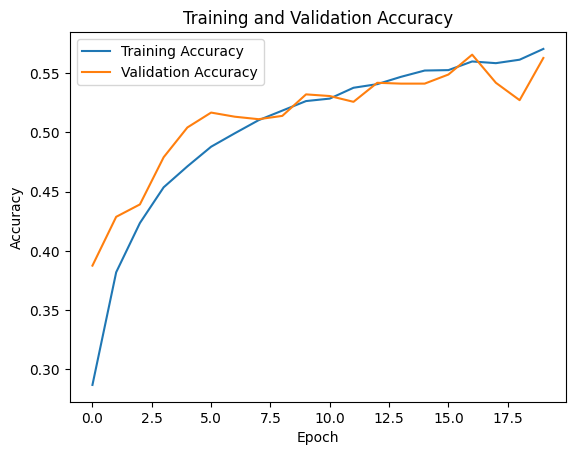

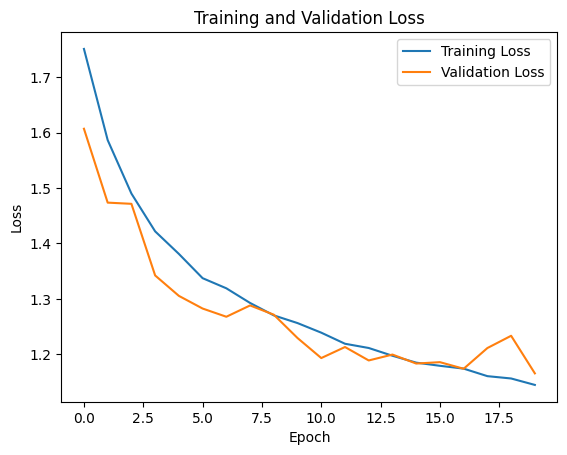

In [42]:
import matplotlib.pyplot as plt

# 정확도 그래프
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 손실 그래프
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

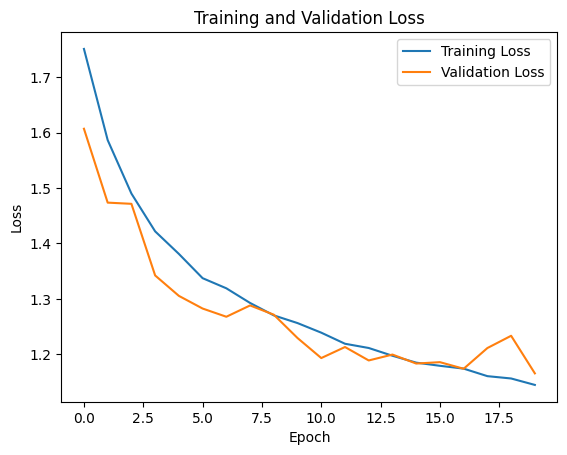

In [43]:
# 손실 그래프
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 [==============================] - 0s 84ms/step
Predicted Emotion: happy
Confidence: 0.28


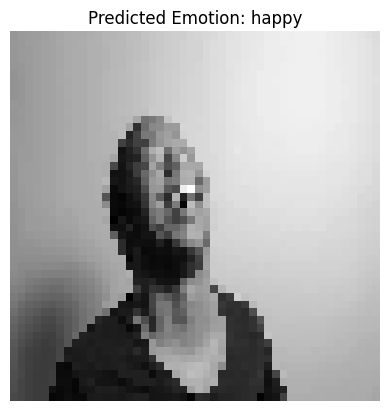

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# 예측하고자 하는 이미지의 파일 경로
img_path = '/content/happy.jpg'

# 이미지 로드 및 전처리
img = image.load_img(img_path, target_size=(48, 48), color_mode="grayscale")
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  # 이미지 정규화

# 모델에 이미지 입력
predictions = model.predict(img_array)

# 예측 결과 출력
class_labels = ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
predicted_label = class_labels[np.argmax(predictions)]
confidence = predictions[0][np.argmax(predictions)]

print(f"Predicted Emotion: {predicted_label}")
print(f"Confidence: {confidence:.2f}")

# 예측 결과 시각화
plt.imshow(img, cmap='gray')
plt.title(f"Predicted Emotion: {predicted_label}")
plt.axis('off')
plt.show()

In [ ]:
import pandas as pd

emoji = '/content/drive/MyDrive/Basic_Emoji/emoji_df.csv'

emoji_df = pd.read_csv(emoji)

# 데이터프레임 출력
print(emoji_df)

        emoji                             name              group  \
0           😀                    grinning face  Smileys & Emotion   
1           😃      grinning face with big eyes  Smileys & Emotion   
2           😄  grinning face with smiling eyes  Smileys & Emotion   
3           😁   beaming face with smiling eyes  Smileys & Emotion   
4           😆          grinning squinting face  Smileys & Emotion   
...       ...                              ...                ...   
4719       🇿🇲                     flag: Zambia              Flags   
4720       🇿🇼                   flag: Zimbabwe              Flags   
4721  🏴󠁧󠁢󠁥󠁮󠁧󠁿                    flag: England              Flags   
4722  🏴󠁧󠁢󠁳󠁣󠁴󠁿                   flag: Scotland              Flags   
4723  🏴󠁧󠁢󠁷󠁬󠁳󠁿                      flag: Wales              Flags   

             sub_group                                 codepoints  
0         face-smiling                                      1F600  
1         face-smiling             

In [ ]:
#데이터 전처리
selected_data = emoji_df.iloc[0:105, 0]
print(selected_data)

0      😀
1      😃
2      😄
3      😁
4      😆
      ..
100    😫
101    🥱
102    😤
103    😡
104    😠
Name: emoji, Length: 105, dtype: object


In [ ]:
#이모지를 이미지로 변환
from PIL import Image, ImageDraw, ImageFont
import os

# 저장할 디렉토리 생성
output_directory = 'emoji_images'
os.makedirs(output_directory, exist_ok=True)

# 이모지를 이미지로 저장
for i, emoji in enumerate(selected_data):
    emoji_image = Image.new('RGB', (48, 48), color='white')  # 48x48 크기의 흰 배경 이미지 생성
    emoji_draw = ImageDraw.Draw(emoji_image)

    # 이미지 저장
    image_filename = f"{output_directory}/emoji_{i + 1}.png"
    emoji_image.save(image_filename)

print(f"Images saved to {output_directory}")

Images saved to emoji_images


#기본 이모지를 변환하고자 시도하였지만 모든 이미지가 흰배경 이미지로 변환되어 데이터 전처리에 실패하였습니다.
#데이터를 수집하는 과정에서 기본 이모지를 수집하는 것은 기업의 자산에 속한 소유물이기 때문에 깔끔하게 정리된 데이터를 찾기 어려웠습니다.
#기한 내에 프로젝트를 완수하지 못하였습니다.